## 图像读入与通道分离、合并

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os 

dir_name = os.path.join(os.getcwd(),"photos")

In [3]:
dir_name

'/home/ai4sc/Desktop/Junior-year-experiment/photos'

In [4]:
img = cv2.imread(os.path.join(dir_name,"leaf.jpg"))

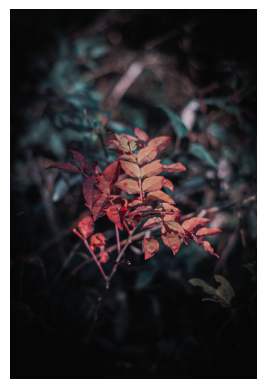

In [5]:
img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.axis("off")
plt.show()


In [6]:
# 图像基本信息
print(f"形状 (shape)       : {img.shape}")          # (H, W, C)
print(f"高度 (height)      : {img.shape[0]} px")
print(f"宽度 (width)       : {img.shape[1]} px")
print(f"通道数 (channels)  : {img.shape[2]}")
print(f"数据类型 (dtype)   : {img.dtype}")
print(f"像素总数           : {img.size}")
print(f"占用内存           : {img.nbytes / 1024:.2f} KB")
print(f"取值范围           : [{img.min()}, {img.max()}]")

形状 (shape)       : (1200, 800, 3)
高度 (height)      : 1200 px
宽度 (width)       : 800 px
通道数 (channels)  : 3
数据类型 (dtype)   : uint8
像素总数           : 2880000
占用内存           : 2812.50 KB
取值范围           : [0, 255]


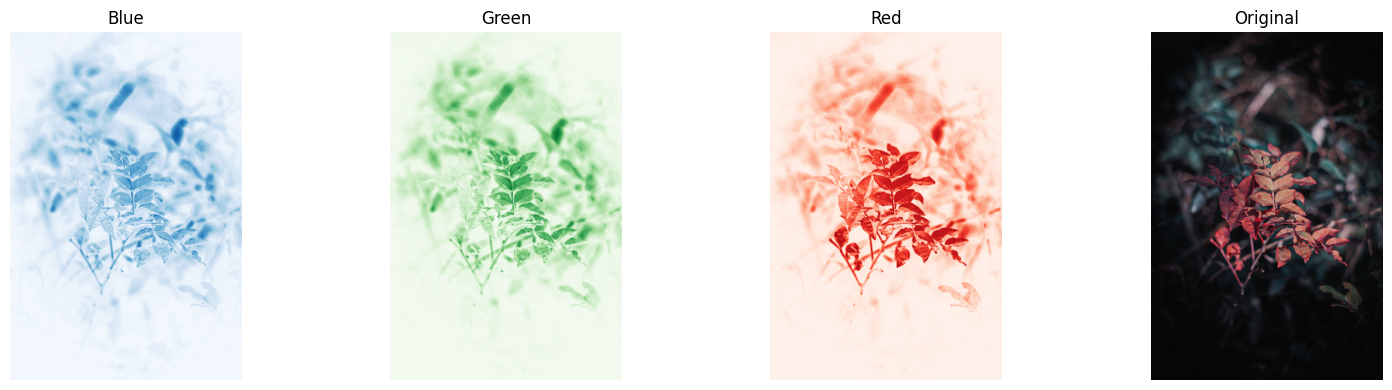

In [7]:
img = cv2.imread(os.path.join(dir_name, "leaf.jpg"))
b, g, r = cv2.split(img)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, channel, title, cmap in zip(
    axes,
    [b, g, r, cv2.cvtColor(img, cv2.COLOR_BGR2RGB)],
    ["Blue", "Green", "Red", "Original"],
    ["Blues", "Greens", "Reds", None],
):
    ax.imshow(channel, cmap=cmap)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [8]:
print(f"蓝色通道 (Blue)   : shape={b.shape}, dtype={b.dtype}, min={b.min()}, max={b.max()}")
print(f"绿色通道 (Green)  : shape={g.shape}, dtype={g.dtype}, min={g.min()}, max={g.max()}")
print(f"红色通道 (Red)    : shape={r.shape}, dtype={r.dtype}, min={r.min()}, max={r.max()}")

蓝色通道 (Blue)   : shape=(1200, 800), dtype=uint8, min=0, max=226
绿色通道 (Green)  : shape=(1200, 800), dtype=uint8, min=0, max=216
红色通道 (Red)    : shape=(1200, 800), dtype=uint8, min=0, max=255


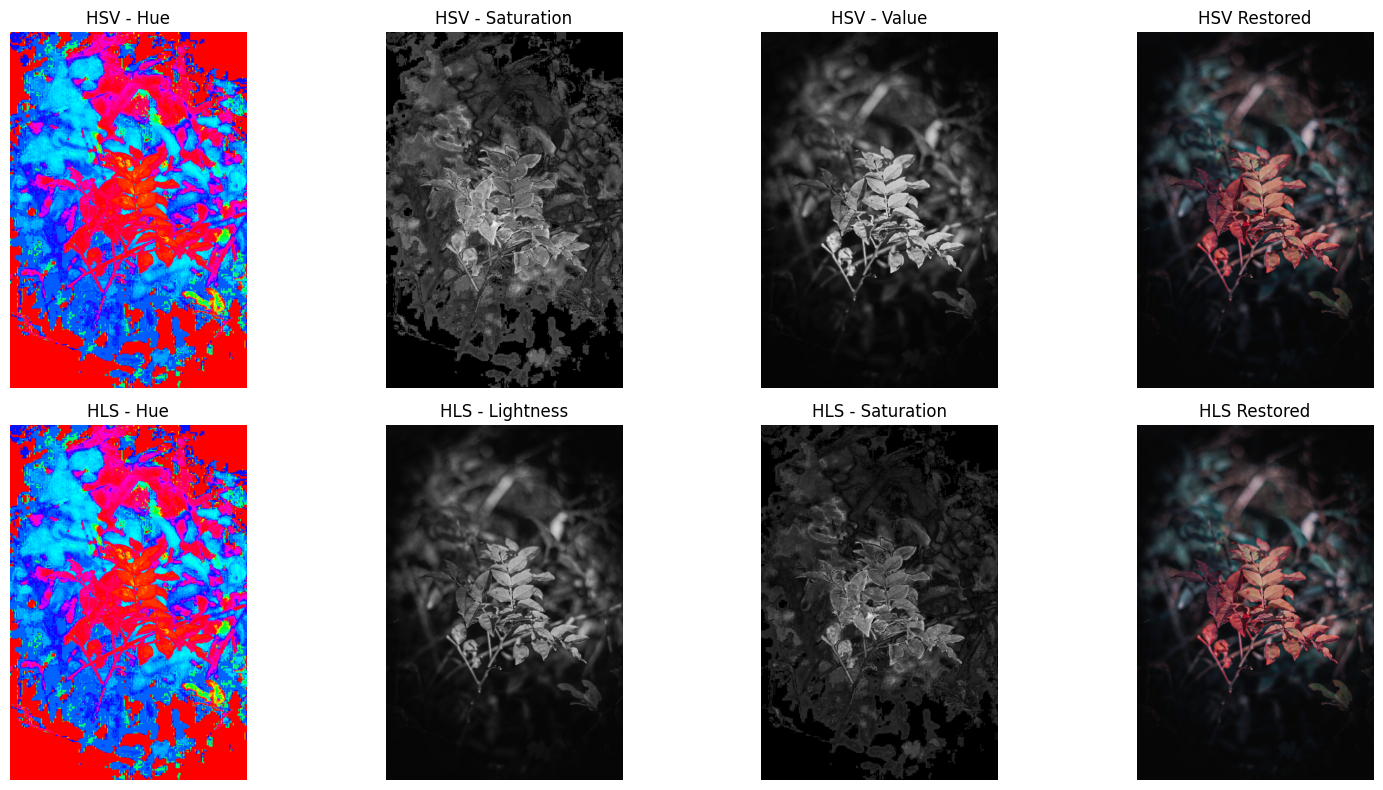

In [9]:
img = cv2.imread(os.path.join(dir_name, "leaf.jpg"))
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
hls = cv2.cvtColor(img, cv2.COLOR_BGR2HLS)

h_hsv, s_hsv, v = cv2.split(hsv)
h_hls, l, s_hls = cv2.split(hls)

img_restored_hsv = cv2.cvtColor(cv2.merge([h_hsv, s_hsv, v]), cv2.COLOR_HSV2RGB)
img_restored_hls = cv2.cvtColor(cv2.merge([h_hls, l, s_hls]), cv2.COLOR_HLS2RGB)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, ch, title, cmap in zip(
    axes.flat,
    [h_hsv, s_hsv, v, img_restored_hsv,
     h_hls, l, s_hls, img_restored_hls],
    ["HSV - Hue", "HSV - Saturation", "HSV - Value",      "HSV Restored",
     "HLS - Hue", "HLS - Lightness",  "HLS - Saturation", "HLS Restored"],
    ["hsv", "gray", "gray", None,
     "hsv", "gray", "gray", None],
):
    ax.imshow(ch, cmap=cmap)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 图像裁剪及加减乘除运算

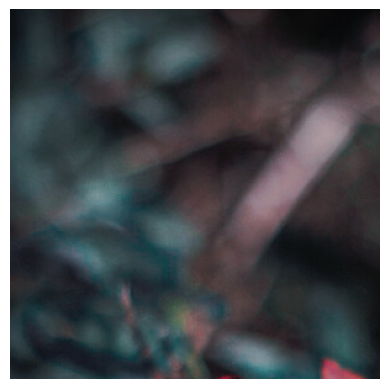

In [10]:
img = cv2.imread(os.path.join(dir_name, "leaf.jpg"))

#图像的裁剪
crop_img = img[100:400, 150:450]  # 裁剪(150,100)到(450,400)的区域
crop_img_rgb = cv2.cvtColor(crop_img, cv2.COLOR_BGR2RGB)
plt.imshow(crop_img_rgb)
plt.axis("off")
plt.show()

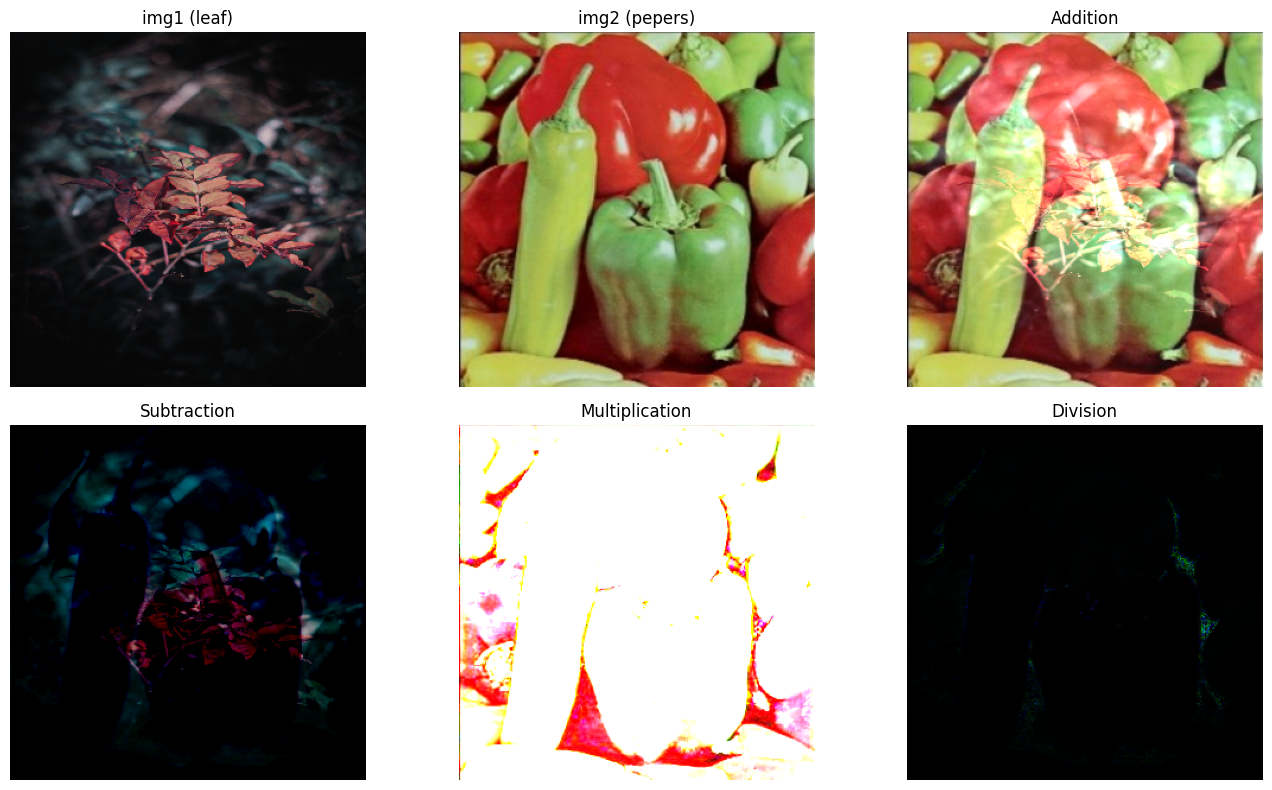

In [11]:
# 选取两张不同图像，统一缩放后进行加减乘除运算
img1 = cv2.imread(os.path.join(dir_name, "leaf.jpg"))
img2 = cv2.imread(os.path.join(dir_name, "pepers.jpg"))
img1 = cv2.resize(img1, (300, 300))
img2 = cv2.resize(img2, (300, 300))

add_img = cv2.add(img1, img2)
sub_img = cv2.subtract(img1, img2)
mul_img = cv2.multiply(img1, img2)
div_img = cv2.divide(img1, img2)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, im, title in zip(
    axes.flat,
    [img1, img2, add_img, sub_img, mul_img, div_img],
    ["img1 (leaf)", "img2 (pepers)", "Addition", "Subtraction", "Multiplication", "Division"],
):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 图像直方图的绘制

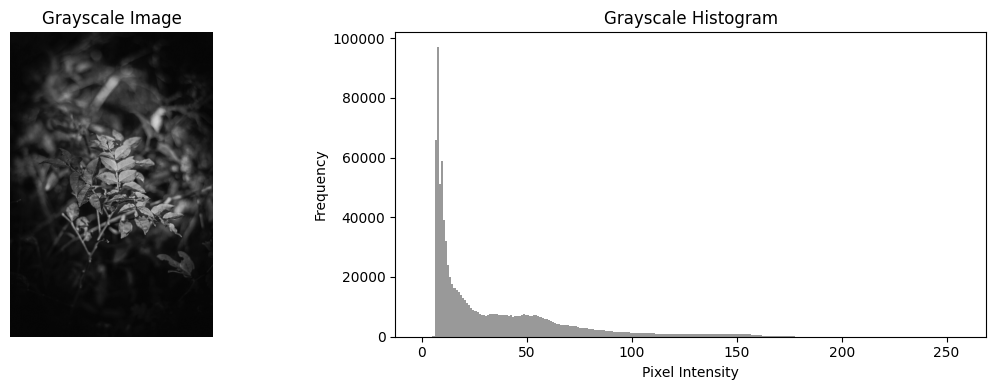

In [12]:
img = cv2.imread(os.path.join(dir_name, "leaf.jpg"))
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(gray, cmap="gray")
axes[0].set_title("Grayscale Image")
axes[0].axis("off")

axes[1].hist(gray.ravel(), bins=256, range=(0, 256), color="gray", alpha=0.8)
axes[1].set_title("Grayscale Histogram")
axes[1].set_xlabel("Pixel Intensity")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

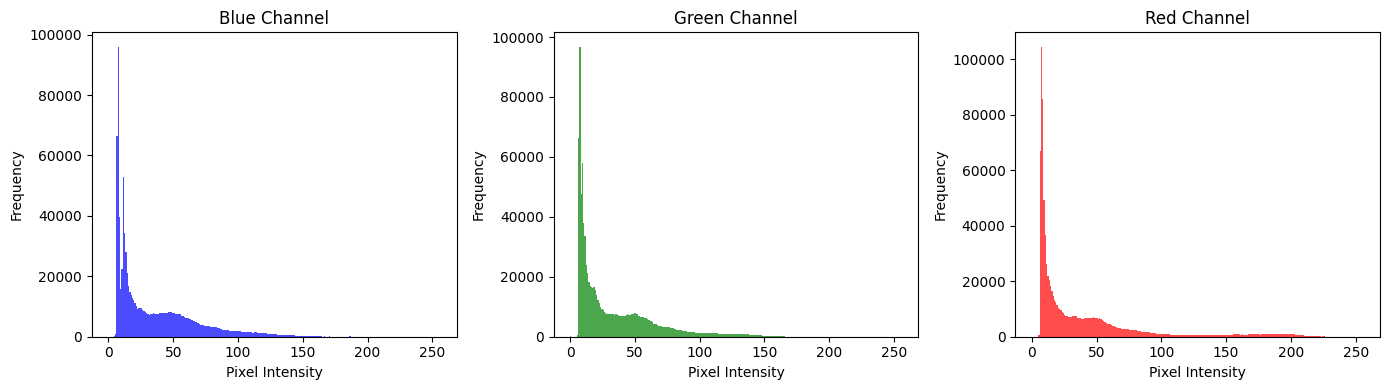

In [13]:
# 分B、G、R三通道绘制直方图
img = cv2.imread(os.path.join(dir_name, "leaf.jpg"))
b, g, r = cv2.split(img)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, ch, title, color in zip(
    axes,
    [b, g, r],
    ["Blue Channel", "Green Channel", "Red Channel"],
    ["blue", "green", "red"],
):
    ax.hist(ch.ravel(), bins=256, range=(0, 256), color=color, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel("Pixel Intensity")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## 基础几何变换（平移、镜像、错切）


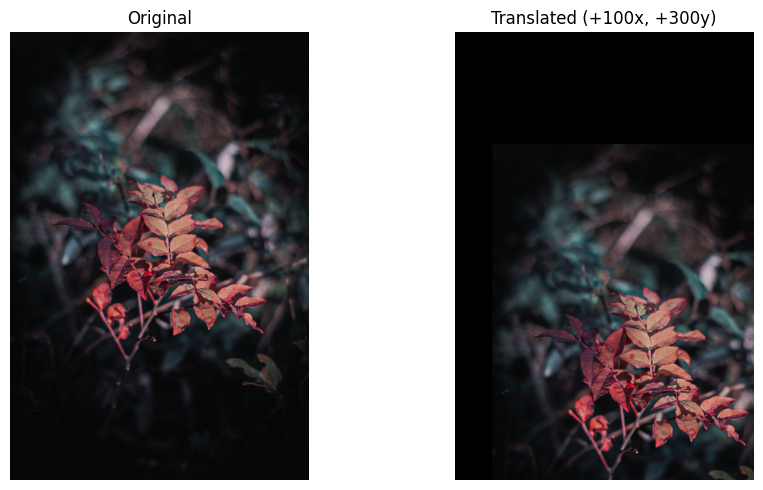

In [14]:
# 实现图像的平移
img = cv2.imread(os.path.join(dir_name, "leaf.jpg"))
rows, cols = img.shape[:2]
M = np.float32([[1, 0, 100], [0, 1, 300]])  # 平移矩阵：右移100像素，下移300像素
translated_img = cv2.warpAffine(img, M, (cols, rows))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(translated_img, cv2.COLOR_BGR2RGB))
axes[1].set_title("Translated (+100x, +300y)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

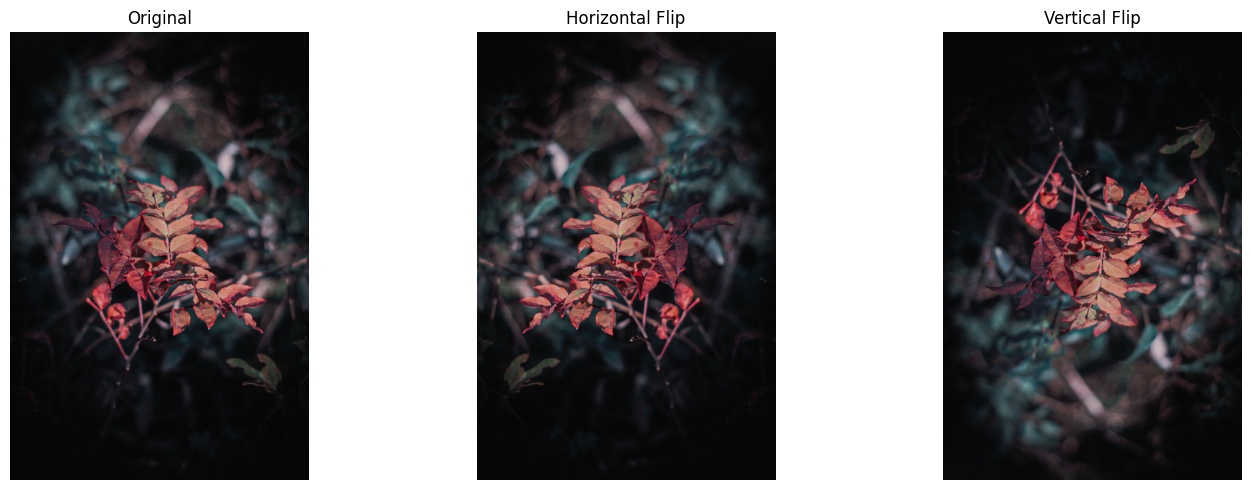

In [15]:
# 实现数字图像的水平镜像和垂直镜像
img = cv2.imread(os.path.join(dir_name, "leaf.jpg"))
h_flip = cv2.flip(img, 1)  # 水平镜像
v_flip = cv2.flip(img, 0)  # 垂直镜像
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, im, title in zip(
    axes,
    [img, h_flip, v_flip],
    ["Original", "Horizontal Flip", "Vertical Flip"],
):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")  
plt.tight_layout()
plt.show()


$$\begin{bmatrix} x' \ y' \end{bmatrix} = \begin{bmatrix} 1 & s_x \ 0 & 1 \end{bmatrix} \begin{bmatrix} x \ y \end{bmatrix}$$

即：
$$x' = x + s_x \cdot y, \quad y' = y$$

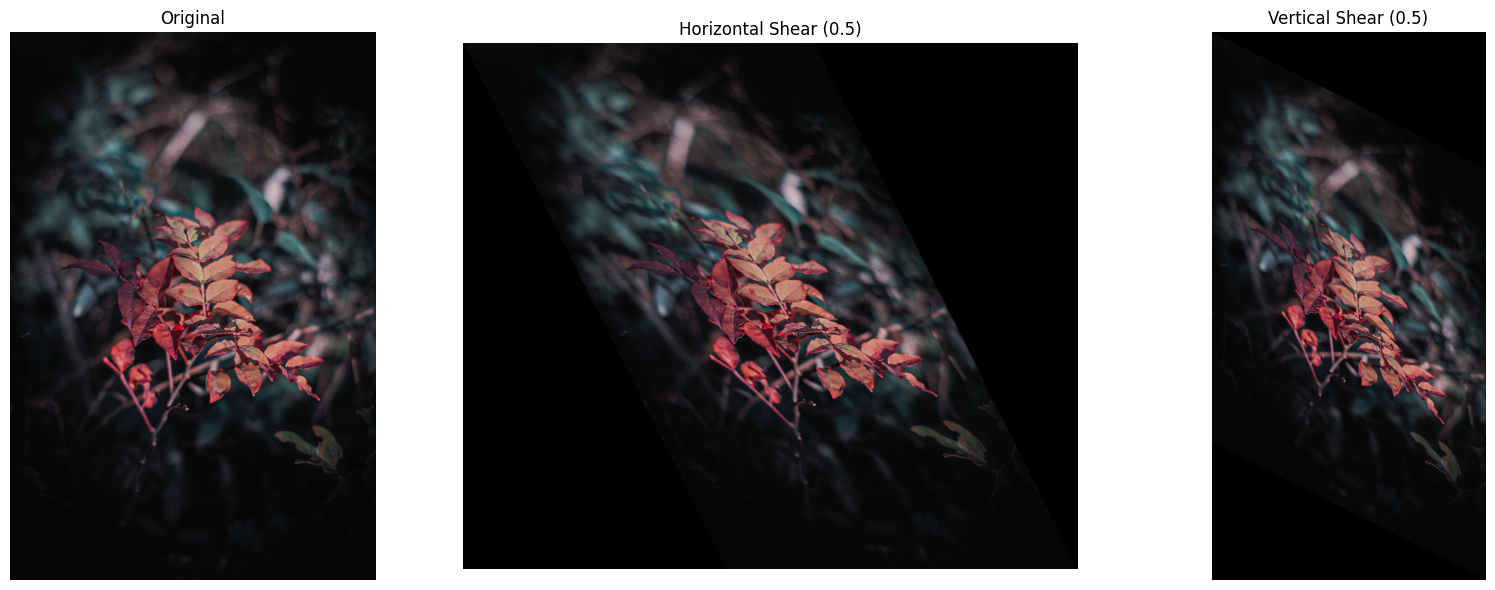

In [22]:
# 实现图像的水平错切和垂直错切
img = cv2.imread(os.path.join(dir_name, "leaf.jpg"))
rows, cols = img.shape[:2]
# 水平错切矩阵
# x' = x + m*y ,  y' = y
M_shear_x = np.float32([[1, 0.5, 0], [0, 1, 0]])  # 水平错切：x方向错切系数为0.5
sheared_x = cv2.warpAffine(img, M_shear_x, (cols + int(0.5 * rows), rows))
# 垂直错切矩阵
# y' = m*x +y , x' = x
M_shear_y = np.float32([[1, 0, 0], [0.5, 1, 0]])  # 垂直错切：y方向错切系数为0.5
sheared_y = cv2.warpAffine(img, M_shear_y, (cols, rows + int(0.5 * cols)))
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, im, title in zip(
    axes,
    [img, sheared_x, sheared_y],
    ["Original", "Horizontal Shear (0.5)", "Vertical Shear (0.5)"],
):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

1. 在仿射变换中水平错切时，由于opencv的坐标原点是在画面的左上角，x坐标轴往右边变大，y坐标轴往下边变大。因此原本的坐标点在仿射变换之后，相同y坐标的点它的x坐标就更大。

## 图像缩放与插值方法对比

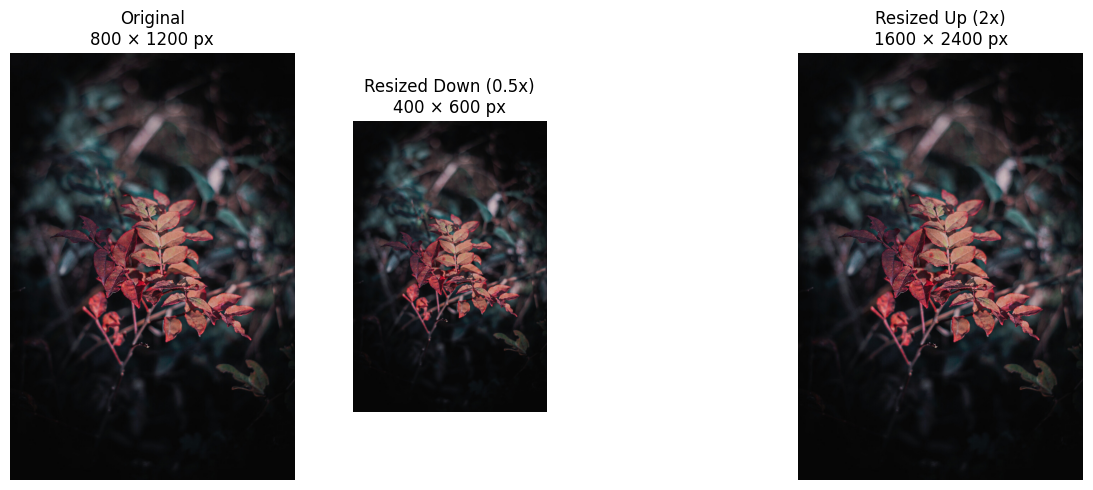

In [17]:
# 选取一张数字图像，使用默认插值方法分别实现0.5倍缩小和2倍放大
img = cv2.imread(os.path.join(dir_name, "leaf.jpg"))
resized_down = cv2.resize(img, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)
resized_up   = cv2.resize(img, None, fx=2.0, fy=2.0, interpolation=cv2.INTER_CUBIC)

images = [img, resized_down, resized_up]
titles = ["Original", "Resized Down (0.5x)", "Resized Up (2x)"]

# figsize 按实际像素宽度比例分配，直观体现缩放差异
widths = [im.shape[1] for im in images]
total = sum(widths)
fig, axes = plt.subplots(1, 3, figsize=(14, 5),
                         gridspec_kw={"width_ratios": widths})
for ax, im, title in zip(axes, images, titles):
    h, w = im.shape[:2]
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{title}\n{w} × {h} px")
    ax.axis("off")

plt.tight_layout()
plt.show()

| 常量 | 算法 | 适合场景 |
|------|------|----------|
| INTER_NEAREST | 最近邻（直接取最近像素） | 速度最快，质量最差，像素风 |
| INTER_LINEAR | 双线性插值（默认） | 速度与质量均衡 |
| INTER_AREA | 区域插值 | 缩小图像首选，抗锯齿效果好 |
| INTER_CUBIC | 双三次插值（4×4邻域） | 放大图像首选，边缘更平滑 |
| INTER_LANCZOS4 | Lanczos（8×8邻域） | 质量最高，速度最慢 |

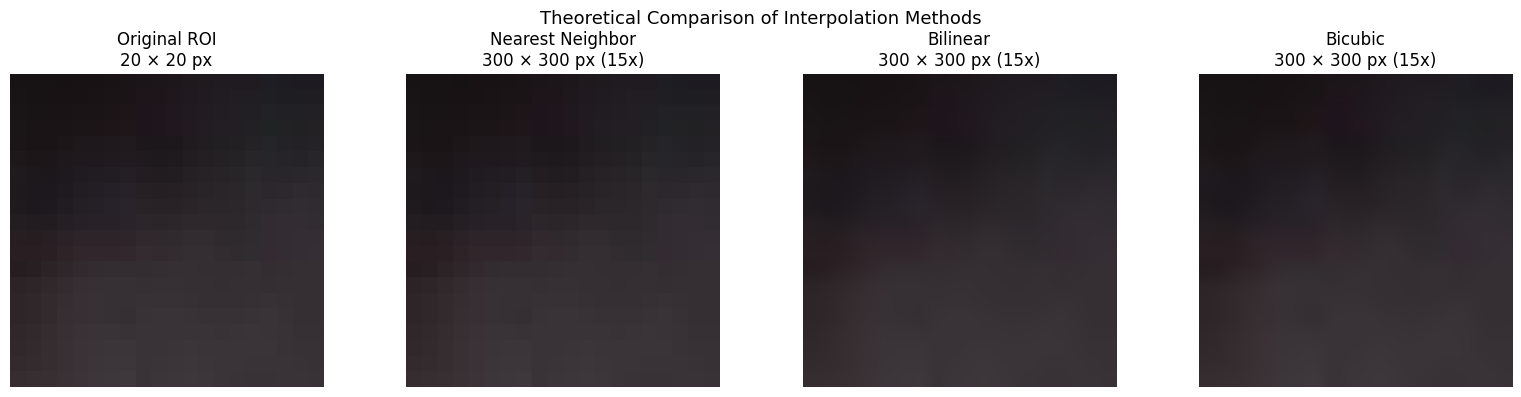

In [ ]:
# 分别使用最近邻插值、双线性插值、双三次插值三种方法，对同一数字图像进行放大
# 取极小区域 + 高倍放大，才能看出插值差异
img = cv2.imread(os.path.join(dir_name, "leaf.jpg"))

methods = {
    "Nearest Neighbor": cv2.INTER_NEAREST,  # 最近邻算法
    "Bilinear":          cv2.INTER_LINEAR,  # 双线性插值
    "Bicubic":           cv2.INTER_CUBIC,   # 双三次插值
}

roi = img[220:240, 320:340]   # 仅 20×20 像素的边缘区域

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(cv2.cvtColor(roi, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original ROI\n20 × 20 px")
axes[0].axis("off")

for ax, (name, method) in zip(axes[1:], methods.items()):
    zoomed = cv2.resize(roi, (300, 300), interpolation=method)
    ax.imshow(cv2.cvtColor(zoomed, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{name}\n300 × 300 px (15x)")
    ax.axis("off")

plt.suptitle("Theoretical Comparison of Interpolation Methods", fontsize=13)
plt.tight_layout()
plt.show()

## 几何校正

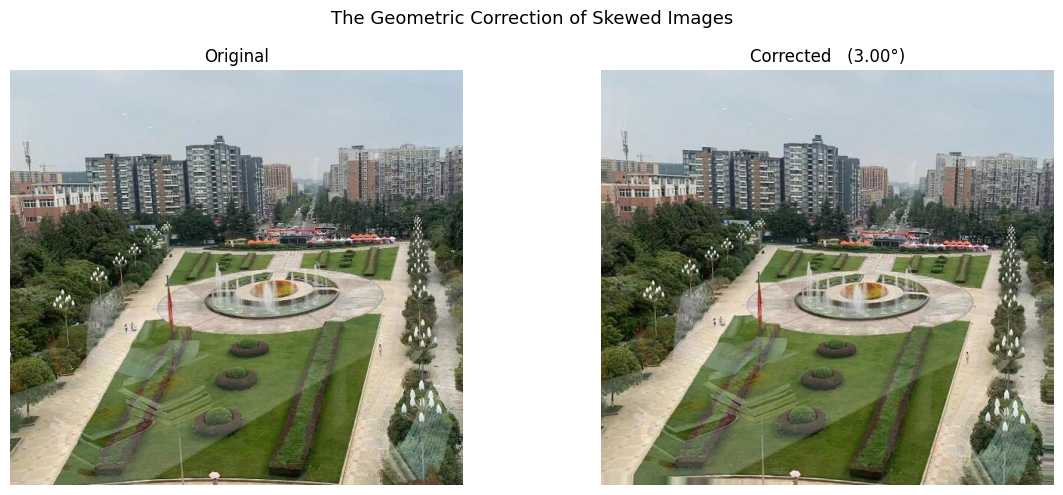

检测倾斜角: -3.00°  →  校正旋转: 3.00°


In [ ]:
img = cv2.imread(os.path.join(dir_name, "school2-1.jpg"))
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 1. Canny 边缘 + HoughLines 估计主方向角度
edges = cv2.Canny(gray, 50, 150) # 提取边缘
lines = cv2.HoughLines(edges, 1, np.pi / 180, 100) # 100 为投票阈值,至少100个点共线才算一条线

angles = []
for l in lines[:20]:
    rho, theta = l[0]
    # 弧度制转角度制
    angle = np.degrees(theta) - 90
    # 过滤直线
    if abs(angle) < 45:
        angles.append(angle)

# 旋转角
skew_angle = float(np.median(angles)) if angles else 0.0

# 2. 以图像中心为旋转中心，反向旋转校正
h, w = img.shape[:2]
M = cv2.getRotationMatrix2D((w / 2, h / 2), skew_angle, 1.0)
corrected = cv2.warpAffine(img, M, (w, h),
                           flags=cv2.INTER_CUBIC,
                           borderMode=cv2.BORDER_REPLICATE)

# 3. 可视化
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, im, title in zip(
    axes,
    [img, corrected],
    ["Original", f"Corrected   ({-skew_angle:.2f}°)"],
):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")

plt.suptitle("The Geometric Correction of Skewed Images", fontsize=13)
plt.tight_layout()
plt.show()

print(f"检测倾斜角: {skew_angle:.2f}°  →  校正旋转: {-skew_angle:.2f}°")

- Canny 提取边缘, 50/150是低/高阈值
- HoughLines 在边缘图检测直线 返回的是极坐标
- 旋转用双三次插值填充新像素,边缘更平滑
- borderMode, 旋转后四角出现的空白区域,用边缘像素复制

## 图像合成

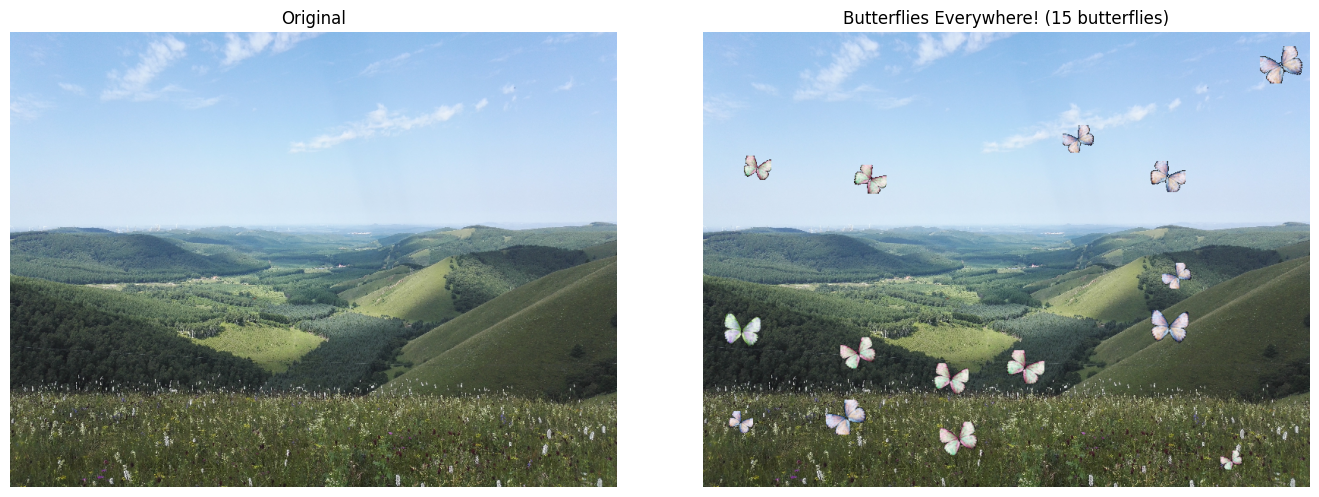

In [ ]:
bmp = cv2.imread(os.path.join(dir_name, "img7_1.bmp"))   # 蝴蝶 157×180
img = cv2.imread(os.path.join(dir_name, "img7_2.jpg"))   # 草地 1944×2576

canvas = cv2.resize(img, (800, 600))
ch, cw = canvas.shape[:2]
bh, bw = bmp.shape[:2]

rng = np.random.default_rng(42)
N =15 # 蝴蝶数量

# 用网格均匀划分区域，保证蝴蝶分散
grid_cols, grid_rows = 6, 5
# 把整个画布分成30个小网格
cell_w, cell_h = cw // grid_cols, ch // grid_rows

positions = [(c * cell_w, r * cell_h) for r in range(grid_rows) for c in range(grid_cols)]
rng.shuffle(positions)

result = canvas.copy()

for i in range(N):
    b = bmp.copy()

    # 1. 随机几何变换：小尺寸缩放(0.15~0.35) + 随机旋转
    scale = rng.uniform(0.15, 0.35)
    angle = rng.uniform(-45, 45)
    new_w = max(int(bw * scale), 4)
    new_h = max(int(bh * scale), 4)
    b = cv2.resize(b, (new_w, new_h))
    M = cv2.getRotationMatrix2D((new_w / 2, new_h / 2), angle, 1.0)
    b = cv2.warpAffine(b, M, (new_w, new_h))

    # 2. 随机交换两个色彩通道
    ch_idx = rng.choice(3, size=2, replace=False)
    b_ch = list(cv2.split(b))
    b_ch[ch_idx[0]], b_ch[ch_idx[1]] = b_ch[ch_idx[1]], b_ch[ch_idx[0]]
    b = cv2.merge(b_ch)

    # 3. 在对应网格单元内随机偏移，保证分散
    base_x, base_y = positions[i % len(positions)]
    offset_x = int(rng.integers(0, max(cell_w - new_w, 1)))
    offset_y = int(rng.integers(0, max(cell_h - new_h, 1)))
    x = min(base_x + offset_x, cw - new_w)
    y = min(base_y + offset_y, ch - new_h)

    gray_b = cv2.cvtColor(b, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray_b, 20, 255, cv2.THRESH_BINARY)
    mask_inv = cv2.bitwise_not(mask)

    roi = result[y:y + new_h, x:x + new_w]
    bg  = cv2.bitwise_and(roi, roi, mask=mask_inv)
    fg  = cv2.bitwise_and(b,   b,   mask=mask)
    result[y:y + new_h, x:x + new_w] = cv2.add(bg, fg)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, im, title in zip(
    axes,
    [canvas, result],
    ["Original", f"Butterflies Everywhere! ({N} butterflies)"],
):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()